In [9]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA is available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version PyTorch was built with: {torch.version.cuda}")
    print(f"Current CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA is available: True
CUDA version PyTorch was built with: 12.4
Current CUDA device name: NVIDIA A100-SXM4-40GB


In [1]:
!pip install koreanize-matplotlib sdv catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.1/198.1 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/2

In [17]:
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta
from bisect import bisect_left, bisect_right

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# SDV (데이터 증강) 라이브러리
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# 전처리 및 모델링 라이브러리
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# 평가 라이브러리
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

import warnings
try:
    import koreanize_matplotlib
except ImportError:
    pass
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/거래_이상탐지_프로젝트/data'

Mounted at /content/drive/


In [4]:
train_df = pd.read_csv(path+"/fraudTrain.csv")
test_df = pd.read_csv(path+"/fraudTest.csv")

In [5]:
def calculate_age(born, trans_date):
    return relativedelta(trans_date, born).years

def count_past_days_fast(df, days):
    results = []
    grouped = df.groupby('cc_num')

    for card, group in grouped:
        times = group['trans_date_trans_time'].tolist()
        counts = []
        for i, t in enumerate(times):
            start_time = t - pd.Timedelta(days=days)
            # 왼쪽 경계 (start_time 이상)
            left_idx = bisect_left(times, start_time)
            # 오른쪽 경계는 현재 거래 바로 전(i번째 거래 제외)
            right_idx = i
            counts.append(right_idx - left_idx)
        results.extend(counts)
    return results

def preprocess_data(df: pd.DataFrame,
                    hour: str = 'sincos',
                    high_risk_period: bool = False,
                    age_group: bool = False
                    ) -> pd.DataFrame:
    '''
    Arg)
    df : 데이터프레임
    hour : 시간 전처리방법 (sincos : sin/cos 변환 , is_night : 'is_night' 칼럼 사용)
    high_risk_period : high_risk_period 사용여부 (Default : False)
    age_group : age_group 사용여부 (Default : False)
    '''

    # 원본 데이터프레임 복사
    df_p = df.copy()

    drop_cols = ['Unnamed: 0', 'unix_time', 'trans_num', 'first', 'last', 'merchant', 'street', 'merch_lat', 'merch_long', 'city_pop', 'lat', 'long', 'zip']
    df_p = df_p.drop(columns=drop_cols)

    # 로그 변환
    df_p['amt_log'] = np.log1p(df_p['amt'])

    # 표준화
    scaler = StandardScaler()
    df_p['amt_log_std'] = scaler.fit_transform(df_p[['amt_log']])

    # datetime 변환
    df_p['datetime'] = pd.to_datetime(df_p['trans_date_trans_time'])

    # 시(hour) 추출 (0~23)
    df_p['hour'] = df_p['datetime'].dt.hour

    # 요일 추출: Monday=0, Sunday=6
    df_p['day_of_week'] = df_p['datetime'].dt.dayofweek

    # 월 추출: 1월=1, 12월=12
    df_p['month'] = df_p['datetime'].dt.month

    # Hour : SinCos변환 or Is_night 사용
    if hour == 'sincos':
        df_p['trans_hour_sin'] = np.sin(2 * np.pi * df_p['hour'] / 24)
        df_p['trans_hour_cos'] = np.cos(2 * np.pi * df_p['hour'] / 24)
    elif hour == 'is_night':
        df_p['is_night'] = df_p['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)


    # higt_rist_period 사용여부
    if high_risk_period:
        # 금(4), 목(3), 수(2) + 심야 시간대(0~4, 21~23)
        high_risk_days = [2, 3, 4]  # 수, 목, 금
        high_risk_hours = list(range(0, 5)) + [21, 22, 23]

        df_p['is_high_risk_period'] = (
            df_p['day_of_week'].isin(high_risk_days) & df_p['hour'].isin(high_risk_hours)
        ).astype(int)

    df_p['trans_date_trans_time'] = pd.to_datetime(df_p['trans_date_trans_time'])
    df_p = df_p.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

    df_p['cnt_1d'] = count_past_days_fast(df_p, 1)
    df_p['cnt_7d'] = count_past_days_fast(df_p, 7)
    df_p['cnt_30d'] = count_past_days_fast(df_p, 30)

    df_p['next_trans_time'] = df_p.groupby('cc_num')['trans_date_trans_time'].shift(-1)
    df_p['time_since_last_trans'] = (df_p['trans_date_trans_time'] - df_p.groupby('cc_num')['trans_date_trans_time'].shift(1)).dt.total_seconds()

    # 또는 마지막 거래 이후 경과 시간(다음 거래까지 시간 간격)
    df_p['time_until_next_trans'] = (df_p['next_trans_time'] - df_p['trans_date_trans_time']).dt.total_seconds()

    # 결측치 처리 (time_since_last_trans 첫 거래는 NaN, 0으로 채우거나 다른 방식)
    df_p[['time_since_last_trans', 'time_until_next_trans']] = df_p[['time_since_last_trans', 'time_until_next_trans']].fillna(0)


    df_p['dob'] = pd.to_datetime(df_p['dob'])

    df_p['age'] = df_p.apply(lambda x: calculate_age(x['dob'], x['trans_date_trans_time']), axis=1)

    if age_group:
        df_p['age_group'] = (df_p['age'] // 10) * 10
        df_p = df_p.drop(columns=['age'])


    # Job 칼럼 Target Encoding + Smoothing ( 아직 없음 )

    df_p['city_state'] = df_p['city'] + ', ' + df_p['state']

    # 최종 Drop
    drop_cols = ['trans_date_trans_time', 'dob', 'next_trans_time', 'cc_num', 'datetime', 'time_until_next_trans', 'city', 'state', 'amt', 'amt_log', 'hour']
    df_p = df_p.drop(columns=drop_cols)

    return df_p

In [6]:
# K-Fold, 타겟 인코딩 스무딩 함수
def m_estimate_smoothing(mean, global_mean, count, m):
    """M-estimate 스무딩을 적용하여 평균을 계산합니다."""
    return (mean * count + global_mean * m) / (count + m)

def kfold_target_encoding(df, target_col, cat_cols, n_splits=5, m_param=10):
    """
    K-Fold 교차 검증 방식의 타겟 인코딩을 M-estimate 스무딩과 함께 적용합니다.
    주어진 cat_cols 리스트에 있는 모든 컬럼에 대해 OOF 인코딩을 적용하고,
    각 컬럼에 대한 Full 인코딩 맵과 전역 평균을 반환합니다.

    Args:
        df: 입력 데이터프레임 (훈련 데이터).
        target_col: 타겟 컬럼 이름 (예: 'is_fraud').
        cat_cols: 인코딩하고 값을 덮어쓸 범주형 컬럼 이름의 리스트.
        n_splits: K-Fold 분할 개수.
        m_param: M-estimate 스무딩 파라미터.
    Returns:
        tuple: (OOF 인코딩된 DataFrame, 각 컬럼별 Full 인코딩 맵과 전역 평균을 담은 딕셔너리)
    """
    df_processed = df.copy() # 원본 DataFrame을 직접 수정하지 않기 위해 복사본 사용
    global_mean = df_processed[target_col].mean() # 전체 타겟 변수의 평균 (모든 인코딩에 공통 사용)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 각 범주형 컬럼별로 학습된 Full 인코딩 맵과 전역 평균을 저장할 딕셔너리
    all_learned_encoding_info = {}

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols: # 각 범주형 컬럼에 대해 반복 처리
        print(f"--- '{cat_col}' 컬럼 OOF 인코딩 진행 중 ---")
        temp_oof_encoded_values = np.empty(len(df_processed))
        temp_oof_encoded_values[:] = np.nan # 초기화

        for train_idx, valid_idx in kf.split(df_processed):
            train_fold = df_processed.iloc[train_idx]

            # 훈련 폴드에서 해당 cat_col의 평균 및 개수 집계
            agg = train_fold.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()

            # M-estimate 스무딩 적용
            agg['smoothed'] = m_estimate_smoothing(agg['mean'], global_mean, agg['count'], m_param)
            mapping = dict(zip(agg[cat_col], agg['smoothed']))

            # 유효성 검사 폴드의 해당 cat_col 위치에 스무딩된 값을 매핑
            temp_oof_encoded_values[valid_idx] = df_processed.loc[valid_idx, cat_col].map(mapping).fillna(global_mean)

        # 모든 폴드에 대한 처리가 끝난 후, df_processed에 OOF 인코딩된 값을 덮어씁니다.
        df_processed[cat_col] = temp_oof_encoded_values

        # 현재 컬럼에 대한 Full 인코딩 맵 생성 (테스트 데이터 인코딩에 사용될 예정)
        full_agg = df.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()
        full_agg['smoothed'] = m_estimate_smoothing(full_agg['mean'], global_mean, full_agg['count'], m_param)
        full_encoding_map = dict(zip(full_agg[cat_col], full_agg['smoothed']))

        # 각 컬럼의 맵과 전역 평균을 딕셔너리에 저장
        all_learned_encoding_info[cat_col] = {
            'map': full_encoding_map,
            'global_mean': global_mean # 각 컬럼별 전역 평균은 동일
        }

    return df_processed, all_learned_encoding_info # OOF 인코딩된 DF와 모든 Full 맵/전역 평균 정보 반환


def test_data_target_encoding(df, cat_cols, learned_encoding_info):
    """
    제공된 인코딩 맵과 전역 평균을 사용하여 테스트 데이터프레임의 여러 컬럼을 인코딩합니다.

    Args:
        df: 입력 데이터프레임 (테스트 데이터).
        cat_cols: 인코딩할 범주형 컬럼 이름의 리스트.
        learned_encoding_info: kfold_target_encoding에서 반환된 학습된 인코딩 정보를 담은 딕셔너리.
                               예: {'col1': {'map': map1, 'global_mean': gm1}, 'col2': {'map': map2, 'global_mean': gm2}}
    Returns:
        인코딩된 컬럼이 덮어씌워진 DataFrame.
    """
    df_processed = df.copy()

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols:
        if cat_col not in learned_encoding_info:
            print(f"경고: '{cat_col}' 컬럼에 대한 학습된 인코딩 정보가 없습니다. 해당 컬럼은 인코딩되지 않습니다.")
            continue

        encoding_map = learned_encoding_info[cat_col]['map']
        global_mean = learned_encoding_info[cat_col]['global_mean']

        # 인코딩 값 덮어쓰기: 맵에 없는 값은 해당 컬럼의 전역 평균으로 대체
        df_processed[cat_col] = df_processed[cat_col].map(encoding_map).fillna(global_mean)
        print(f"--- '{cat_col}' 컬럼 테스트 데이터 인코딩 완료 ---")

    return df_processed

In [7]:
X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = test_df.copy()
print("데이터 분할 완료")
print(f"학습: {df_train.shape}, 검증: {df_val.shape}, 테스트: {df_test.shape}\n" + "-"*50)

데이터 분할 완료
학습: (1037340, 23), 검증: (259335, 23), 테스트: (555719, 23)
--------------------------------------------------


In [10]:
print("1차 기본 전처리 시작...")
# preprocess_data 함수가 이미 정의되어 있다고 가정합니다.
train_temp = preprocess_data(df_train, high_risk_period=True, age_group=False)
val_temp = preprocess_data(df_val, high_risk_period=True, age_group=False)
test_temp = preprocess_data(df_test, high_risk_period=True, age_group=False)
print("-> 1차 기본 전처리 완료.")

1차 기본 전처리 시작...
-> 1차 기본 전처리 완료.


In [11]:
print("\nK-Fold 타겟 인코딩 (Smoothing) 시작...")

encoding_features = ['job', 'city_state']
m_param_job = 500
m_param_city_state = 5
n_splits_kfold = 5

train_encoded, learned_info_job = kfold_target_encoding(
    df=train_temp, target_col='is_fraud', cat_cols=['job'],
    n_splits=n_splits_kfold, m_param=m_param_job
)
train_encoded, learned_info_cs = kfold_target_encoding(
    df=train_encoded, target_col='is_fraud', cat_cols=['city_state'],
    n_splits=n_splits_kfold, m_param=m_param_city_state
)

learned_info = {**learned_info_job, **learned_info_cs}

val_encoded = test_data_target_encoding(df=val_temp, cat_cols=encoding_features, learned_encoding_info=learned_info)
test_encoded = test_data_target_encoding(df=test_temp, cat_cols=encoding_features, learned_encoding_info=learned_info)

rename_dict = {'job': 'job_encoded', 'city_state': 'city_state_encoded'}
train_encoded.rename(columns=rename_dict, inplace=True)
val_encoded.rename(columns=rename_dict, inplace=True)
test_encoded.rename(columns=rename_dict, inplace=True)

print(f"\n-> 타겟 인코딩 완료: {list(rename_dict.values())}")


K-Fold 타겟 인코딩 (Smoothing) 시작...
--- 'job' 컬럼 OOF 인코딩 진행 중 ---
--- 'city_state' 컬럼 OOF 인코딩 진행 중 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'job' 컬럼 테스트 데이터 인코딩 완료 ---
--- 'city_state' 컬럼 테스트 데이터 인코딩 완료 ---

-> 타겟 인코딩 완료: ['job_encoded', 'city_state_encoded']


In [12]:
print("\nCTGAN 데이터 증강 시작...")

# 타겟 인코딩만 완료된 학습 데이터로 증강 수행
fraud_data = train_encoded[train_encoded['is_fraud'] == 1]
non_fraud_data = train_encoded[train_encoded['is_fraud'] == 0]

if len(fraud_data) > 0:
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(data=fraud_data)

    # 주의: 이 단계에서는 아직 원핫 인코딩이 되지 않았으므로,
    # 'category'와 'gender'는 CTGAN이 자동으로 'categorical'로 처리하도록 둡니다.
    metadata.update_column(column_name='job_encoded', sdtype='numerical')
    metadata.update_column(column_name='city_state_encoded', sdtype='numerical')

    synthesizer = CTGANSynthesizer(metadata, epochs=300, verbose=False)
    synthesizer.fit(fraud_data)
    synthetic_fraud_data = synthesizer.sample(num_rows=55000)

    # 증강된 데이터와 원본 데이터를 합쳐 새로운 학습 데이터셋 생성
    train_aug = pd.concat([non_fraud_data, fraud_data, synthetic_fraud_data], ignore_index=True)
    train_aug = train_aug.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"-> 데이터 증강 완료 (최종 학습 데이터: {train_aug.shape})")
else:
    print("-> 학습 데이터에 사기 거래가 없어 증강을 건너뜁니다.")
    train_aug = train_encoded

# 검증 및 테스트 데이터는 이 단계에서 변경 없이 그대로 전달
val_pre_ohe = val_encoded
test_pre_ohe = test_encoded


CTGAN 데이터 증강 시작...
-> 데이터 증강 완료 (최종 학습 데이터: (1092340, 16))


In [13]:
print("\n원-핫 인코딩 시작...\n")
categorical_features = ['category', 'gender','day_of_week','is_high_risk_period']

train_final_base = pd.get_dummies(train_aug, columns=categorical_features, dummy_na=False, drop_first=True)
val_final_base = pd.get_dummies(val_pre_ohe, columns=categorical_features, dummy_na=False, drop_first=True)
test_final_base = pd.get_dummies(test_pre_ohe, columns=categorical_features, dummy_na=False, drop_first=True)

train_cols = train_final_base.columns
val_final_base = val_final_base.reindex(columns=train_cols, fill_value=0)
test_final_base = test_final_base.reindex(columns=train_cols, fill_value=0)

print("-> 원-핫 인코딩 및 컬럼 정렬 완료.\n")


원-핫 인코딩 시작...

-> 원-핫 인코딩 및 컬럼 정렬 완료.



In [14]:
train_final_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092340 entries, 0 to 1092339
Data columns (total 33 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   job_encoded              1092340 non-null  float64
 1   is_fraud                 1092340 non-null  int64  
 2   amt_log_std              1092340 non-null  float64
 3   month                    1092340 non-null  int32  
 4   trans_hour_sin           1092340 non-null  float64
 5   trans_hour_cos           1092340 non-null  float64
 6   cnt_1d                   1092340 non-null  int64  
 7   cnt_7d                   1092340 non-null  int64  
 8   cnt_30d                  1092340 non-null  int64  
 9   time_since_last_trans    1092340 non-null  float64
 10  age                      1092340 non-null  int64  
 11  city_state_encoded       1092340 non-null  float64
 12  category_food_dining     1092340 non-null  bool   
 13  category_gas_transport   1092340 non-null 

# 1. Isolation Forest Random Search

In [19]:
def custom_if_scorer(estimator, X, y=None): # y는 사용되지 않지만 make_scorer 요구사항에 맞춰둠
    """
    Isolation Forest의 score_samples()를 사용하여 점수를 계산하는 사용자 정의 스코어.
    score_samples()는 정상성에 대한 점수를 반환하며, 값이 높을수록 정상에 가깝습니다.
    따라서 평균 score_samples 값을 최대화하는 것이 목적입니다.
    """
    return estimator.score_samples(X).mean()

In [21]:
print("\nIsolation Forest 피처 생성 시작 (RandomizedSearchCV 적용 - 스코어링 없음)...\n")

# 1. 수치형 피처만 선택 (is_fraud는 제외)
numeric_cols = train_final_base.select_dtypes(include=['int64', 'float64']).drop(columns=['is_fraud']).columns.tolist()

# 2. Isolation Forest 전용 스케일러를 새로 만듭니다.
scaler_iso = StandardScaler()
X_train_num_scaled_iso = scaler_iso.fit_transform(train_final_base[numeric_cols])
X_val_num_scaled_iso = scaler_iso.transform(val_final_base[numeric_cols])
X_test_num_scaled_iso = scaler_iso.transform(test_final_base[numeric_cols])

# 3. Isolation Forest 모델 및 탐색할 파라미터 공간 정의
iso_forest = IsolationForest(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_samples': [0.1, 0.2, 0.3, 0.4, 0.5, 'auto'],
    'contamination': [0.01, 0.05, 0.1, 'auto'],
    'max_features': [0.5, 0.7, 0.9, 1.0],
}

# Isolation Forest는 비지도 학습 모델이므로,
# RandomizedSearchCV의 scoring 매개변수를 None으로 설정하여 y_true를 사용한
# 명시적인 성능 평가를 건너뛰고, 모델 자체의 score 메서드(decision_function 기반)를 사용하도록 합니다.
# fit 메서드 호출 시에도 y_train을 전달하지 않습니다.
random_search = RandomizedSearchCV(iso_forest, param_distributions=param_dist, n_iter=50, cv=3,
                                   scoring=custom_if_scorer, # 여기에 None을 설정하여 점수 매기기를 명시적으로 제거
                                   random_state=42, n_jobs=-1, verbose=2)

print("RandomizedSearchCV를 이용한 Isolation Forest 파라미터 조합 탐색 중...\n")
random_search.fit(X_train_num_scaled_iso)

print("-> RandomizedSearchCV 파라미터 조합 탐색 완료.\n")
# 모든 RandomizedSearchCV 조합의 결과를 저장할 리스트
all_iforest_results = []

print("모든 RandomizedSearchCV 조합에 대해 Isolation Forest 피처 생성 및 저장 중...\n")

# cv_results_에서 각 조합의 파라미터를 가져와 모델을 학습하고 피처 생성
for i in range(len(random_search.cv_results_['params'])):
    params = random_search.cv_results_['params'][i]
    # 'mean_test_score'는 scoring=None일 때 IsolationForest.score() 값으로 채워지지만,
    # 사용자 요구에 따라 이 값을 직접 사용하거나 의미를 부여하지 않아도 됩니다.
    # mean_test_score = random_search.cv_results_['mean_test_score'][i] # 더 이상 명시적으로 표시할 필요 없음

    print(f"--- 조합 {i+1}/{len(random_search.cv_results_['params'])} (파라미터: {params}) ---")

    # 현재 조합의 파라미터로 Isolation Forest 모델 생성 및 학습
    current_iso_model = IsolationForest(random_state=42, n_jobs=-1, **params)
    current_iso_model.fit(X_train_num_scaled_iso) # Isolation Forest는 비지도 학습이므로 y_train 불필요

    # 각 데이터프레임의 복사본 생성 (원본 유지)
    current_train_final = train_final_base.copy()
    current_val_final = val_final_base.copy()
    current_test_final = test_final_base.copy()

    # (1) 학습 데이터에 적용
    current_train_final['iforest_score'] = current_iso_model.decision_function(X_train_num_scaled_iso)
    current_train_final['iforest_outlier'] = current_iso_model.predict(X_train_num_scaled_iso).astype(int)
    current_train_final['iforest_outlier'] = current_train_final['iforest_outlier'].map({1: 0, -1: 1}) # 이상치(-1)를 1로 매핑

    # (2) 검증 데이터에 적용
    current_val_final['iforest_score'] = current_iso_model.decision_function(X_val_num_scaled_iso)
    current_val_final['iforest_outlier'] = current_iso_model.predict(X_val_num_scaled_iso).astype(int)
    current_val_final['iforest_outlier'] = current_val_final['iforest_outlier'].map({1: 0, -1: 1})

    # (3) 테스트 데이터에 적용
    current_test_final['iforest_score'] = current_iso_model.decision_function(X_test_num_scaled_iso)
    current_test_final['iforest_outlier'] = current_iso_model.predict(X_test_num_scaled_iso).astype(int)
    current_test_final['iforest_outlier'] = current_test_final['iforest_outlier'].map({1: 0, -1: 1})

    # 결과를 리스트에 딕셔너리 형태로 저장
    all_iforest_results.append({
        'params': params,
        # 'mean_test_score': mean_test_score, # 스코어링을 원치 않으므로 이 라인은 주석 처리하거나 제거
        'train_df_with_features': current_train_final,
        'val_df_with_features': current_val_final,
        'test_df_with_features': current_test_final
    })
    print("-> 피처 생성 완료.\n")

print("모든 조합에 대한 Isolation Forest 피처 생성 및 저장 완료.\n")
print(f"총 {len(all_iforest_results)}개의 결과 조합이 'all_iforest_results' 변수에 저장되었습니다.")

# 'all_iforest_results' 변수를 사용하여 각 조합의 데이터프레임에 접근할 수 있습니다.
# 예시: 첫 번째 조합의 학습 데이터프레임에 접근
# first_combination_train_df = all_iforest_results[0]['train_df_with_features']
# print(first_combination_train_df.head())


Isolation Forest 피처 생성 시작 (RandomizedSearchCV 적용 - 스코어링 없음)...

RandomizedSearchCV를 이용한 Isolation Forest 파라미터 조합 탐색 중...

Fitting 3 folds for each of 50 candidates, totalling 150 fits
-> RandomizedSearchCV 파라미터 조합 탐색 완료.

모든 RandomizedSearchCV 조합에 대해 Isolation Forest 피처 생성 및 저장 중...

--- 조합 1/50 (파라미터: {'n_estimators': 50, 'max_samples': 0.2, 'max_features': 1.0, 'contamination': 0.1}) ---
-> 피처 생성 완료.

--- 조합 2/50 (파라미터: {'n_estimators': 200, 'max_samples': 0.3, 'max_features': 0.9, 'contamination': 0.1}) ---
-> 피처 생성 완료.

--- 조합 3/50 (파라미터: {'n_estimators': 300, 'max_samples': 0.5, 'max_features': 0.9, 'contamination': 'auto'}) ---
-> 피처 생성 완료.

--- 조합 4/50 (파라미터: {'n_estimators': 50, 'max_samples': 'auto', 'max_features': 0.7, 'contamination': 'auto'}) ---
-> 피처 생성 완료.

--- 조합 5/50 (파라미터: {'n_estimators': 50, 'max_samples': 0.3, 'max_features': 0.9, 'contamination': 0.01}) ---
-> 피처 생성 완료.

--- 조합 6/50 (파라미터: {'n_estimators': 50, 'max_samples': 0.4, 'max_features': 1.0, 'contaminat

In [68]:
all_iforest_results[0]['train_df_with_features'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092340 entries, 0 to 1092339
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   job_encoded              1092340 non-null  float64
 1   is_fraud                 1092340 non-null  int64  
 2   amt_log_std              1092340 non-null  float64
 3   month                    1092340 non-null  int32  
 4   trans_hour_sin           1092340 non-null  float64
 5   trans_hour_cos           1092340 non-null  float64
 6   cnt_1d                   1092340 non-null  int64  
 7   cnt_7d                   1092340 non-null  int64  
 8   cnt_30d                  1092340 non-null  int64  
 9   time_since_last_trans    1092340 non-null  float64
 10  age                      1092340 non-null  int64  
 11  city_state_encoded       1092340 non-null  float64
 12  category_food_dining     1092340 non-null  bool   
 13  category_gas_transport   1092340 non-null 

## Stacking(LGBM, XGB, CatBoost) -> Random Search 한 결과

In [39]:
best_f1_score = -1
best_recall_score = -1
best_iforest_params = None
best_stacking_model = None # 최적 스태킹 모델 저장용
best_train_final_df = None # 최적 IF 조합으로 생성된 train_final 데이터프레임
best_val_final_df = None   # 최적 IF 조합으로 생성된 val_final 데이터프레임
best_test_final_df = None  # 최적 IF 조합으로 생성된 test_final 데이터프레임
best_X_train_scaled = None
best_X_val_scaled = None
best_X_test_scaled = None

# 시각화를 위한 리스트 초기화
validation_f1_scores = []
validation_recall_scores = []

# 테스트 세트 성능 저장을 위한 리스트 추가
test_f1_scores = []
test_recall_scores = []

iforest_param_labels = [] # 각 조합의 파라미터를 저장하여 x축 레이블로 사용

# 스태킹 기본 모델들 정의 (루프 밖에서 한 번만 정의하여 효율성 증대 및 메시지 중복 방지)
# GPU 사용 설정 시도: 각 라이브러리가 GPU 버전을 설치해야 함
# (예: pip install lightgbm --install-option=--gpu, pip install xgboost, pip install catboost)
# 또는 conda를 통해 설치 시 GPU 지원 패키지를 설치해야 합니다.

# LightGBM Classifier (GPU 지원)
try:
    lgbm_clf = LGBMClassifier(random_state=42, n_jobs=-1, verbose=0, device='gpu')
    print("LightGBM: GPU 사용 설정 완료 (device='gpu').")
except Exception as e:
    lgbm_clf = LGBMClassifier(random_state=42, n_jobs=-1, verbose=0)
    print(f"LightGBM: GPU 설정 중 오류 발생 ({e}). CPU로 폴백합니다.")

# XGBoost Classifier (GPU 지원)
try:
    xgb_clf = XGBClassifier(random_state=42, n_jobs=-1, tree_method='gpu_hist', eval_metric='logloss')
    print("XGBoost: GPU 사용 설정 완료 (tree_method='gpu_hist').")
except Exception as e:
    xgb_clf = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
    print(f"XGBoost: GPU 설정 중 오류 발생 ({e}). CPU로 폴백합니다.")

# CatBoost Classifier (GPU 지원)
try:
    cat_clf = CatBoostClassifier(random_state=42, verbose=0, task_type='GPU')
    print("CatBoost: GPU 사용 설정 완료 (task_type='GPU').")
except Exception as e:
    cat_clf = CatBoostClassifier(random_state=42, verbose=0)
    print(f"CatBoost: GPU 설정 중 오류 발생 ({e}). CPU로 폴백합니다.")

# 최종 모델(Meta-Learner) 정의 (LogisticRegression은 scikit-learn에서 GPU를 직접 지원하지 않음 - CPU 사용)
meta_clf = LogisticRegression(random_state=42, n_jobs=-1)

LightGBM: GPU 사용 설정 완료 (device='gpu').
XGBoost: GPU 사용 설정 완료 (tree_method='gpu_hist').
CatBoost: GPU 사용 설정 완료 (task_type='GPU').


In [54]:
print("\n===== 모든 Isolation Forest 조합에 대해 스태킹 앙상블 모델 학습 및 평가 시작 =====")
print(f"이 과정은 매우 오래 걸릴 수 있습니다 (총 {len(all_iforest_results)}개의 조합).\n")

for i, iforest_result in enumerate(all_iforest_results):
    current_iforest_params = iforest_result['params']
    current_train_final = iforest_result['train_df_with_features']
    current_val_final = iforest_result['val_df_with_features']
    current_test_final = iforest_result['test_df_with_features'] # 이제 is_fraud 컬럼이 있다고 가정합니다.

    print(f"\n--- Isolation Forest 조합 {i+1}/{len(all_iforest_results)} 시작 (IF 파라미터: {current_iforest_params}) ---")
    print("현재 IF 조합에 대한 최종 데이터셋 생성 및 스케일링 중...")

    # 피처(X)와 타겟(y) 분리
    X_train_final = current_train_final.drop('is_fraud', axis=1)
    y_train_final = current_train_final['is_fraud']

    X_val_final = current_val_final.drop('is_fraud', axis=1).reindex(columns=X_train_final.columns, fill_value=0)
    y_val_final = current_val_final['is_fraud']

    X_test_final = current_test_final.drop('is_fraud', axis=1).reindex(columns=X_train_final.columns, fill_value=0)
    y_test_final = current_test_final['is_fraud']

    # --- 데이터 스케일링 로직 변경 시작 ---

    # 1. Boolean 컬럼 식별
    boolean_cols = X_train_final.select_dtypes(include='bool').columns

    # 2. 스케일링이 필요한 컬럼 식별
    cols_to_scale_now = ['iforest_score']

    # 3. 데이터프레임 복사본 생성 (원본 데이터를 직접 수정하지 않기 위해)
    X_train_scaled = X_train_final.copy()
    X_val_scaled = X_val_final.copy()
    X_test_scaled = X_test_final.copy()

    # 4. StandardScaler 초기화
    scaler_iforest_score = StandardScaler()

    # 5. 스케일링 대상 컬럼에만 스케일러 적용 후, 복사본 데이터프레임의 해당 컬럼에 결과 값을 직접 할당
    # 이렇게 하면 컬럼 누락이나 순서 불일치 없이 스케일링이 적용됩니다.
    X_train_scaled[cols_to_scale_now] = scaler_iforest_score.fit_transform(X_train_scaled[cols_to_scale_now])
    X_val_scaled[cols_to_scale_now] = scaler_iforest_score.transform(X_val_scaled[cols_to_scale_now])
    X_test_scaled[cols_to_scale_now] = scaler_iforest_score.transform(X_test_scaled[cols_to_scale_now])

    print("-> 'iforest_score' 값만 추가 스케일링 완료.")
    print("스태킹 모델 학습 시작...")

    # 스태킹 모델 구성 및 학습
    stacking_model = StackingClassifier(
        estimators=[
            ('lgbm', lgbm_clf),
            ('xgb', xgb_clf),
            ('cat', cat_clf)
        ],
        final_estimator=meta_clf,
        cv=3,
        n_jobs=1
    )

    stacking_model.fit(X_train_scaled, y_train_final)
    print("-> 스태킹 모델 학습 완료.")

    # 검증 데이터에 대한 예측 및 평가 (모델 선택을 위한 적절한 방법)
    y_pred_val_stacking = stacking_model.predict(X_val_scaled)
    y_proba_val_stacking = stacking_model.predict_proba(X_val_scaled)[:, 1]

    current_recall_val = recall_score(y_val_final, y_pred_val_stacking)
    current_f1_val = f1_score(y_val_final, y_pred_val_stacking)
    current_roc_auc_val = roc_auc_score(y_val_final, y_proba_val_stacking)

    print(f"  검증 세트 성능: Recall: {current_recall_val:.4f}, F1-Score: {current_f1_val:.4f}, ROC-AUC: {current_roc_auc_val:.4f}")

    # 시각화를 위해 검증 세트 성능 저장
    validation_f1_scores.append(current_f1_val)
    validation_recall_scores.append(current_recall_val)

    # current_iforest_params 딕셔너리에서 숫자 값만 추출하여 레이블 생성
    param_values_str = ", ".join([
        f"{k}:{v}" for k, v in current_iforest_params.items()
        if isinstance(v, (int, float)) # 값이 정수 또는 실수인지 확인
    ])
    iforest_param_labels.append(f"IF {i+1} ({param_values_str})") # x축 레이블 생성

    # ===== 테스트 데이터에 대한 예측 및 평가 수행 (각 모델별로) =====
    print("-> 테스트 데이터에 대한 예측 및 평가 수행 중...")
    y_pred_test_current_model = stacking_model.predict(X_test_scaled)
    y_proba_test_current_model = stacking_model.predict_proba(X_test_scaled)[:, 1]

    # 테스트 데이터 성능 지표 계산
    current_recall_test = recall_score(y_test_final, y_pred_test_current_model)
    current_f1_test = f1_score(y_test_final, y_pred_test_current_model)
    current_roc_auc_test = roc_auc_score(y_test_final, y_proba_test_current_model)

    print(f"  테스트 세트 성능: Recall: {current_recall_test:.4f}, F1-Score: {current_f1_test:.4f}, ROC-AUC: {current_roc_auc_test:.4f}")

    # 테스트 세트 성능 저장을 위한 코드 추가
    test_f1_scores.append(current_f1_test)
    test_recall_scores.append(current_recall_test)
    # =======================================================


    # 최적 조합 업데이트 (검증 세트 F1-score 우선, Recall로 tie-break)
    # **중요**: 모델 선택은 항상 검증 세트 성능을 기준으로 해야 합니다.
    # 테스트 세트 성능은 최종 보고용으로만 사용됩니다.
    if current_f1_val > best_f1_score:
        best_f1_score = current_f1_val
        best_recall_score = current_recall_val # Update both
        best_iforest_params = current_iforest_params
        best_stacking_model = stacking_model # Store the trained model

        # 원본 데이터프레임 복사본 저장
        best_train_final_df = current_train_final.copy()
        best_val_final_df = current_val_final.copy()
        best_test_final_df = current_test_final.copy()

        # 스케일링된 데이터프레임도 함께 저장
        best_X_train_scaled = X_train_scaled.copy()
        best_X_val_scaled = X_val_scaled.copy()
        best_X_test_scaled = X_test_scaled.copy()
    elif current_f1_val == best_f1_score and current_recall_val > best_recall_score:
        best_recall_score = current_recall_val
        best_iforest_params = current_iforest_params
        best_stacking_model = stacking_model

        # 원본 데이터프레임 복사본 저장
        best_train_final_df = current_train_final.copy()
        best_val_final_df = current_val_final.copy()
        best_test_final_df = current_test_final.copy()

        # 스케일링된 데이터프레임도 함께 저장
        best_X_train_scaled = X_train_scaled.copy()
        best_X_val_scaled = X_val_scaled.copy()
        best_X_test_scaled = X_test_scaled.copy()

    print(f"--- Isolation Forest 조합 {i+1}/{len(all_iforest_results)} 완료 ---\n")

print("===== 모든 Isolation Forest 조합에 대한 스태킹 앙상블 모델 학습 및 평가 완료 =====")

print("\n[최고 성능 조합 요약 (검증 세트 기준)]")
print(f"최고 F1-Score (검증 세트): {best_f1_score:.4f}")
print(f"해당 Recall (검증 세트): {best_recall_score:.4f}")
print(f"최적 Isolation Forest 파라미터: {best_iforest_params}")


===== 모든 Isolation Forest 조합에 대해 스태킹 앙상블 모델 학습 및 평가 시작 =====
이 과정은 매우 오래 걸릴 수 있습니다 (총 50개의 조합).


--- Isolation Forest 조합 1/50 시작 (IF 파라미터: {'n_estimators': 50, 'max_samples': 0.2, 'max_features': 1.0, 'contamination': 0.1}) ---
현재 IF 조합에 대한 최종 데이터셋 생성 및 스케일링 중...
-> 'iforest_score' 값만 추가 스케일링 완료.
스태킹 모델 학습 시작...
-> 스태킹 모델 학습 완료.
  검증 세트 성능: Recall: 0.8048, F1-Score: 0.8638, ROC-AUC: 0.9976
-> 테스트 데이터에 대한 예측 및 평가 수행 중...
  테스트 세트 성능: Recall: 0.3795, F1-Score: 0.5118, ROC-AUC: 0.9702
--- Isolation Forest 조합 1/50 완료 ---


--- Isolation Forest 조합 2/50 시작 (IF 파라미터: {'n_estimators': 200, 'max_samples': 0.3, 'max_features': 0.9, 'contamination': 0.1}) ---
현재 IF 조합에 대한 최종 데이터셋 생성 및 스케일링 중...
-> 'iforest_score' 값만 추가 스케일링 완료.
스태킹 모델 학습 시작...
-> 스태킹 모델 학습 완료.
  검증 세트 성능: Recall: 0.7988, F1-Score: 0.8654, ROC-AUC: 0.9971
-> 테스트 데이터에 대한 예측 및 평가 수행 중...
  테스트 세트 성능: Recall: 0.4434, F1-Score: 0.5771, ROC-AUC: 0.9742
--- Isolation Forest 조합 2/50 완료 ---


--- Isolation Forest 조합 3/50 시작 (IF 파라미터: {'

In [75]:
print("best_f1_score :", best_f1_score)
print("best_iforest_params :", best_iforest_params)

best_f1_score : 0.8694096601073346
best_iforest_params : {'n_estimators': 200, 'max_samples': 0.2, 'max_features': 1.0, 'contamination': 0.01}


In [55]:
iforest_param_labels

['IF 1 (n_estimators:50, max_samples:0.2, max_features:1.0, contamination:0.1)',
 'IF 2 (n_estimators:200, max_samples:0.3, max_features:0.9, contamination:0.1)',
 'IF 3 (n_estimators:300, max_samples:0.5, max_features:0.9)',
 'IF 4 (n_estimators:50, max_features:0.7)',
 'IF 5 (n_estimators:50, max_samples:0.3, max_features:0.9, contamination:0.01)',
 'IF 6 (n_estimators:50, max_samples:0.4, max_features:1.0)',
 'IF 7 (n_estimators:100, max_samples:0.3, max_features:0.7, contamination:0.01)',
 'IF 8 (n_estimators:200, max_samples:0.5, max_features:0.5, contamination:0.05)',
 'IF 9 (n_estimators:300, max_samples:0.4, max_features:1.0)',
 'IF 10 (n_estimators:200, max_features:0.7, contamination:0.1)',
 'IF 11 (n_estimators:100, max_samples:0.2, max_features:0.9, contamination:0.1)',
 'IF 12 (n_estimators:200, max_features:0.5, contamination:0.05)',
 'IF 13 (n_estimators:300, max_samples:0.1, max_features:0.5, contamination:0.1)',
 'IF 14 (n_estimators:100, max_features:0.9, contaminatio

In [56]:
simplified_iforest_param_labels = []
for label in iforest_param_labels:
    # 각 레이블에서 'IF 숫자' 부분만 추출합니다.
    # 예: 'IF 1 (n_estimators:50, ...)' -> 'IF 1'
    # 'IF '로 시작하고 그 뒤에 숫자가 오는 패턴을 찾아서 가져옵니다.
    # 괄호가 시작하는 위치를 찾아 그 전까지만 자릅니다.
    if '(' in label:
        simplified_label = label.split('(')[0].strip()
    else:
        # 만약 괄호가 없는 경우 (예: 이미 'IF 1' 같은 형태인 경우)는 그대로 사용합니다.
        simplified_label = label.strip()

    simplified_iforest_param_labels.append(simplified_label)

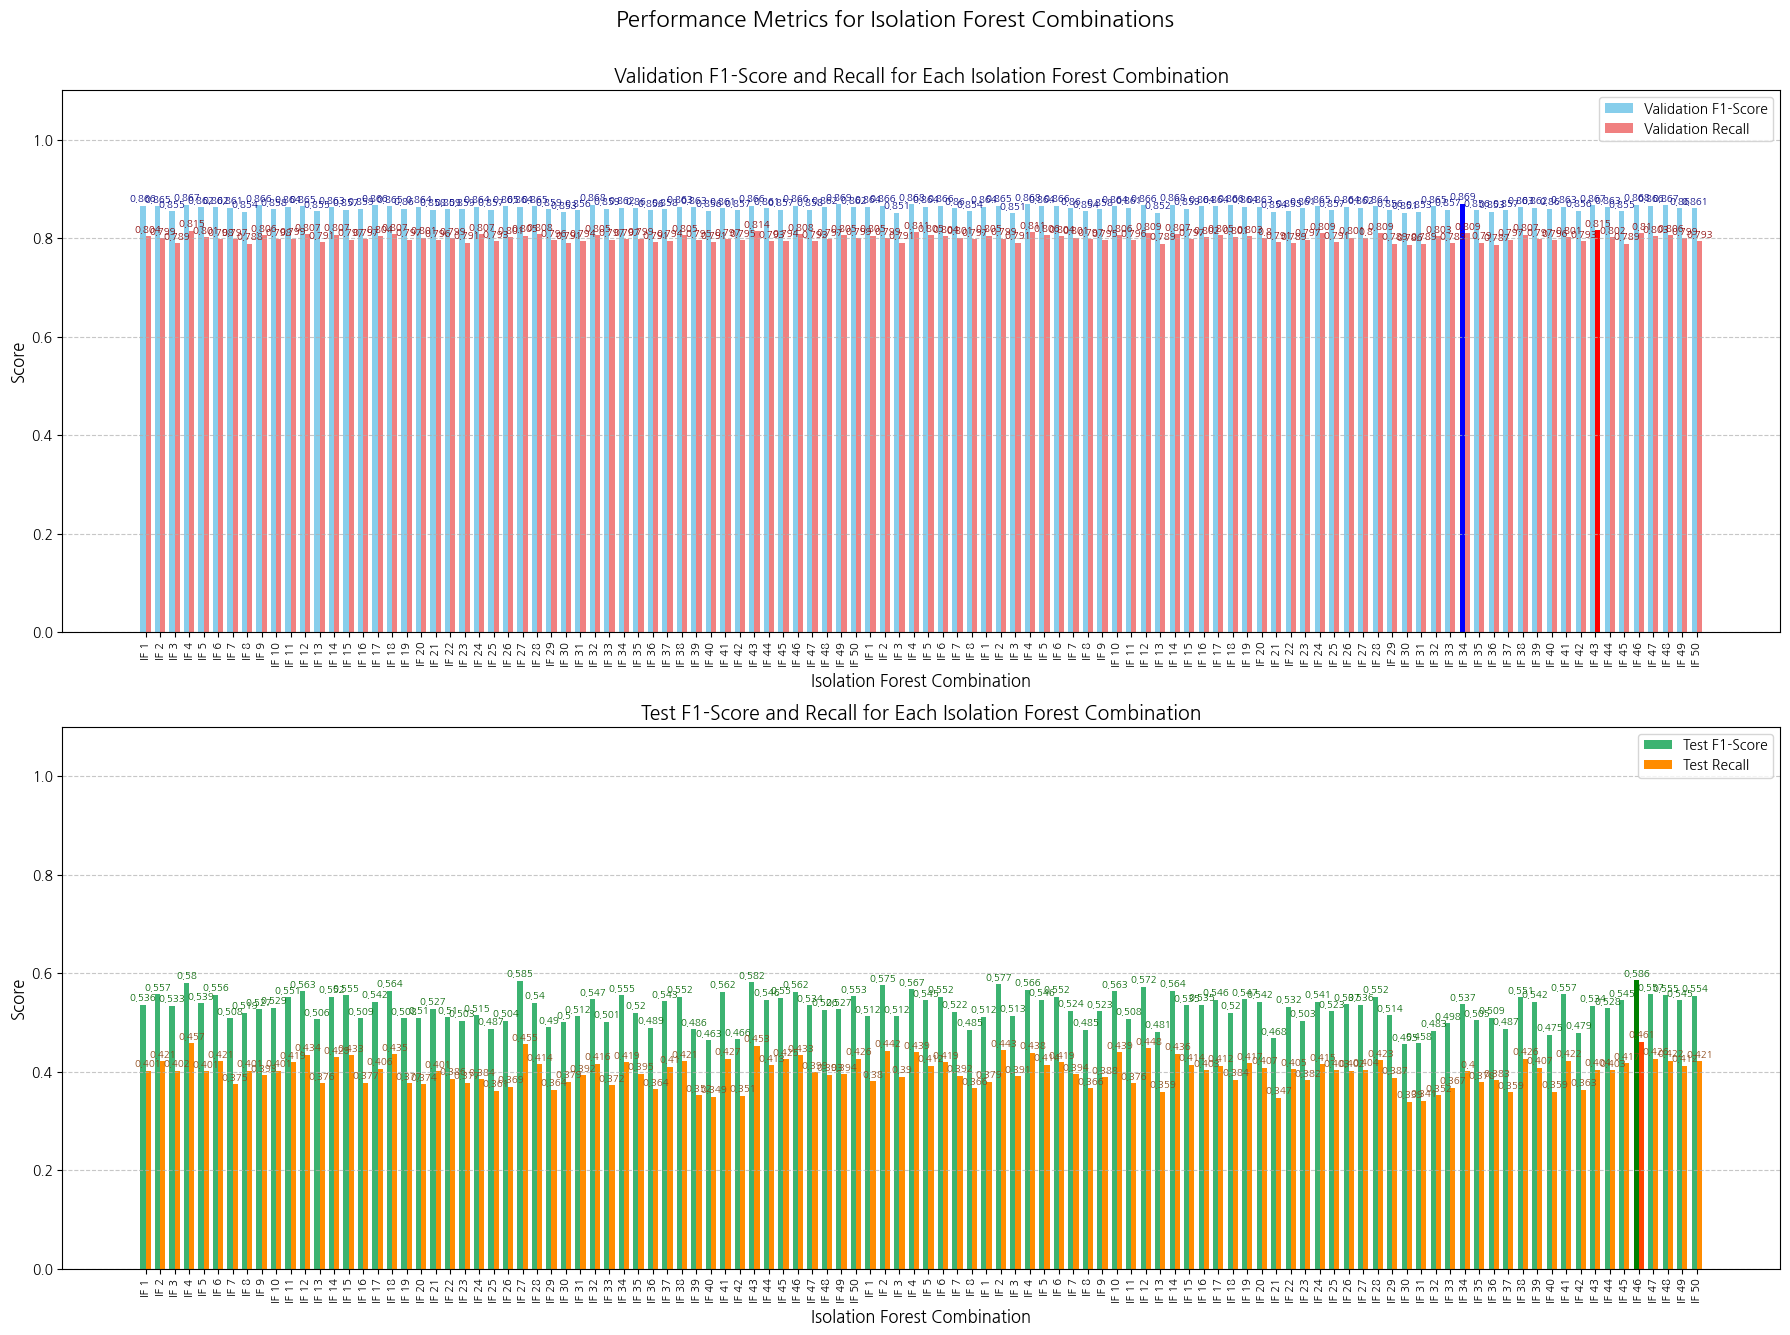

In [57]:
plt.figure(figsize=(18, 14)) # 막대 그래프는 가로축 공간을 더 필요로 할 수 있으므로 폭을 약간 넓힘

# x축 위치를 위한 인덱스 생성
x = np.arange(len(simplified_iforest_param_labels))
width = 0.35 # 막대의 너비

# --- 첫 번째 서브플롯: Validation 성능 시각화 (상단) ---
plt.subplot(2, 1, 1) # 2행 1열 중 첫 번째 그래프 (상단)

# 최고값 인덱스 찾기
best_val_f1_idx = np.argmax(validation_f1_scores)
best_val_recall_idx = np.argmax(validation_recall_scores)

# Validation F1-Score 막대 그래프
colors_f1_val = ['skyblue'] * len(validation_f1_scores)
colors_f1_val[best_val_f1_idx] = 'blue' # 강조색 변경
bars_f1_val = plt.bar(x - width/2, validation_f1_scores, width, label='Validation F1-Score', color=colors_f1_val)

# 각 막대 위에 수치 표시
for bar in bars_f1_val:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), ha='center', va='bottom', fontsize=7, color='navy') # 수치 표시

# Validation Recall 막대 그래프
colors_recall_val = ['lightcoral'] * len(validation_recall_scores)
colors_recall_val[best_val_recall_idx] = 'red' # 강조색 변경
bars_recall_val = plt.bar(x + width/2, validation_recall_scores, width, label='Validation Recall', color=colors_recall_val)

# 각 막대 위에 수치 표시
for bar in bars_recall_val:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), ha='center', va='bottom', fontsize=7, color='darkred') # 수치 표시


plt.title('Validation F1-Score and Recall for Each Isolation Forest Combination', fontsize=14)
plt.xlabel('Isolation Forest Combination', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(x, simplified_iforest_param_labels, rotation=90, ha='center', fontsize=8) # x축 레이블 위치 및 회전
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Y축에만 그리드 표시
plt.legend(loc='best', fontsize=10)
plt.ylim(bottom=0, top=1.1) # Y축 상단 여유 공간 확보 (수치 표시 때문에)


# --- 두 번째 서브플롯: Test 성능 시각화 (하단) ---
plt.subplot(2, 1, 2) # 2행 1열 중 두 번째 그래프 (하단)

# 최고값 인덱스 찾기
best_test_f1_idx = np.argmax(test_f1_scores)
best_test_recall_idx = np.argmax(test_recall_scores)

# Test F1-Score 막대 그래프
colors_f1_test = ['mediumseagreen'] * len(test_f1_scores)
colors_f1_test[best_test_f1_idx] = 'green' # 강조색 변경
bars_f1_test = plt.bar(x - width/2, test_f1_scores, width, label='Test F1-Score', color=colors_f1_test)

# 각 막대 위에 수치 표시
for bar in bars_f1_test:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), ha='center', va='bottom', fontsize=7, color='darkgreen') # 수치 표시

# Test Recall 막대 그래프
colors_recall_test = ['darkorange'] * len(test_recall_scores)
colors_recall_test[best_test_recall_idx] = 'orangered' # 강조색 변경
bars_recall_test = plt.bar(x + width/2, test_recall_scores, width, label='Test Recall', color=colors_recall_test)

# 각 막대 위에 수치 표시
for bar in bars_recall_test:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), ha='center', va='bottom', fontsize=7, color='saddlebrown') # 수치 표시


plt.title('Test F1-Score and Recall for Each Isolation Forest Combination', fontsize=14)
plt.xlabel('Isolation Forest Combination', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(x, simplified_iforest_param_labels, rotation=90, ha='center', fontsize=8)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='best', fontsize=10)
plt.ylim(bottom=0, top=1.1) # Y축 상단 여유 공간 확보


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Performance Metrics for Isolation Forest Combinations', fontsize=16, y=0.98)
plt.show()

## 모델 평가 시각화

In [58]:
def evaluate_and_visualize(model, X_data, y_data, set_name):
    """모델 평가 및 결과/혼동 행렬 시각화 함수"""
    y_pred = model.predict(X_data)
    y_pred_proba = model.predict_proba(X_data)[:, 1]

    results = {
        'Precision': precision_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred),
        'F1-Score': f1_score(y_data, y_pred),
        'ROC_AUC': roc_auc_score(y_data, y_pred_proba)
    }

    print(f"\n--- {set_name} 평가 결과 ---")
    print(pd.DataFrame([results]).to_string())
    print("\nClassification Report:")
    print(classification_report(y_data, y_pred, digits=4))

    cm = confusion_matrix(y_data, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=['정상(0)', '사기(1)'], yticklabels=['정상(0)', '사기(1)'])
    plt.title(f'Confusion Matrix ({set_name})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return results



--- Validation Set 평가 결과 ---
   Precision   Recall  F1-Score   ROC_AUC
0   0.938949  0.80946   0.86941  0.997386

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9997    0.9993    257834
           1     0.9389    0.8095    0.8694      1501

    accuracy                         0.9986    259335
   macro avg     0.9689    0.9046    0.9344    259335
weighted avg     0.9985    0.9986    0.9985    259335



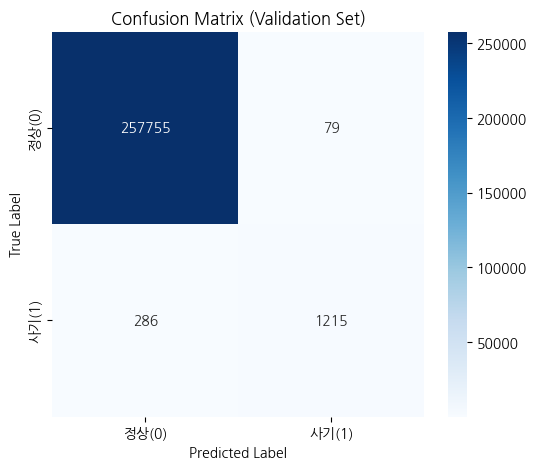



--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.825296  0.422844  0.559186  0.974182

Classification Report:
              precision    recall  f1-score   support

           0     0.9978    0.9997    0.9987    553574
           1     0.8253    0.4228    0.5592      2145

    accuracy                         0.9974    555719
   macro avg     0.9115    0.7112    0.7789    555719
weighted avg     0.9971    0.9974    0.9970    555719



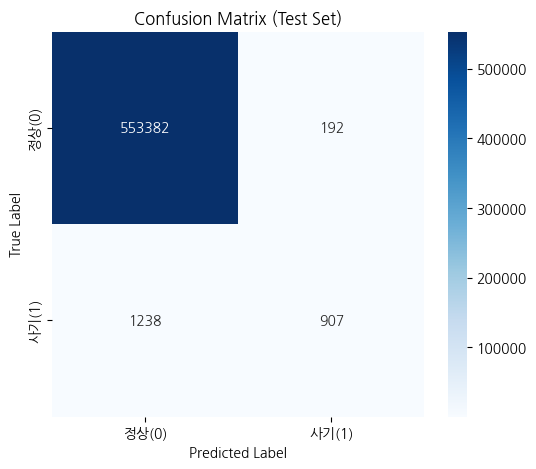

In [59]:
# 검증 데이터 평가
print("\n" + "="*50)
stacking_results = evaluate_and_visualize(best_stacking_model, best_X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
test_results = evaluate_and_visualize(stacking_model, best_X_test_scaled, y_test_final, "Test Set")

# 2. isolation baseline

In [60]:
numeric_cols_for_iso_baseline = train_final_base.select_dtypes(include=['int64', 'float64']).drop(columns=['is_fraud']).columns.tolist()

# Isolation Forest 전용 스케일러를 새로 만듭니다.
scaler_iso_baseline = StandardScaler()
X_train_num_scaled_iso_baseline = scaler_iso_baseline.fit_transform(train_final_base[numeric_cols_for_iso_baseline])

# 검증 및 테스트 데이터는 transform만 적용
X_val_num_scaled_iso_baseline = scaler_iso_baseline.transform(val_final_base[numeric_cols_for_iso_baseline])
X_test_num_scaled_iso_baseline = scaler_iso_baseline.transform(test_final_base[numeric_cols_for_iso_baseline])

# 베이스라인 Isolation Forest 모델 파라미터 정의
baseline_if_params = {
    'n_estimators': 100,
    'contamination': 'auto',
    'random_state': 42,
    'n_jobs': -1
}

print(f"Isolation Forest 모델 학습 중 (파라미터: {baseline_if_params})...")

# 단일 Isolation Forest 모델 생성 및 학습
iso_model_baseline = IsolationForest(**baseline_if_params)
iso_model_baseline.fit(X_train_num_scaled_iso_baseline)


# 각 데이터프레임의 복사본 생성 (원본 유지)
# 여기에 iforest_score와 iforest_outlier 피처가 추가될 것입니다.
# 변수명에 '_with_if_features_baseline'을 추가하여 명확하게 구분합니다.
train_df_with_if_features_baseline = train_final_base.copy()
val_df_with_if_features_baseline = val_final_base.copy()
test_df_with_if_features_baseline = test_final_base.copy()

# (1) 학습 데이터에 이상치 점수 및 레이블 적용
train_df_with_if_features_baseline['iforest_score'] = iso_model_baseline.decision_function(X_train_num_scaled_iso_baseline)
train_df_with_if_features_baseline['iforest_outlier'] = iso_model_baseline.predict(X_train_num_scaled_iso_baseline).astype(int)
train_df_with_if_features_baseline['iforest_outlier'] = train_df_with_if_features_baseline['iforest_outlier'].map({1: 0, -1: 1})

# (2) 검증 데이터에 이상치 점수 및 레이블 적용
val_df_with_if_features_baseline['iforest_score'] = iso_model_baseline.decision_function(X_val_num_scaled_iso_baseline)
val_df_with_if_features_baseline['iforest_outlier'] = iso_model_baseline.predict(X_val_num_scaled_iso_baseline).astype(int)
val_df_with_if_features_baseline['iforest_outlier'] = val_df_with_if_features_baseline['iforest_outlier'].map({1: 0, -1: 1})

# (3) 테스트 데이터에 이상치 점수 및 레이블 적용
test_df_with_if_features_baseline['iforest_score'] = iso_model_baseline.decision_function(X_test_num_scaled_iso_baseline)
test_df_with_if_features_baseline['iforest_outlier'] = iso_model_baseline.predict(X_test_num_scaled_iso_baseline).astype(int)
test_df_with_if_features_baseline['iforest_outlier'] = test_df_with_if_features_baseline['iforest_outlier'].map({1: 0, -1: 1})

print("-> Isolation Forest 피처 추가 완료.")
print("\n학습 데이터의 IForest 피처 요약:")
print(train_df_with_if_features_baseline[['iforest_score', 'iforest_outlier']].describe())

Isolation Forest 모델 학습 중 (파라미터: {'n_estimators': 100, 'contamination': 'auto', 'random_state': 42, 'n_jobs': -1})...
-> Isolation Forest 피처 추가 완료.

학습 데이터의 IForest 피처 요약:
       iforest_score  iforest_outlier
count   1.092340e+06     1.092340e+06
mean    3.779294e-02     1.495267e-01
std     3.918103e-02     3.566070e-01
min    -1.902786e-01     0.000000e+00
25%     1.877217e-02     0.000000e+00
50%     4.605225e-02     0.000000e+00
75%     6.613310e-02     0.000000e+00
max     1.094286e-01     1.000000e+00


In [61]:
print("\n최종 데이터셋 생성 및 스케일링 시작...")

# 피처(X)와 타겟(y) 분리
# Isolation Forest 피처가 추가된 데이터프레임에서 X, y 분리
X_train_final_baseline = train_df_with_if_features_baseline.drop('is_fraud', axis=1)
y_train_final_baseline = train_df_with_if_features_baseline['is_fraud']

X_val_final_baseline = val_df_with_if_features_baseline.drop('is_fraud', axis=1).reindex(columns=X_train_final_baseline.columns, fill_value=0)
y_val_final_baseline = val_df_with_if_features_baseline['is_fraud']

X_test_final_baseline = test_df_with_if_features_baseline.drop('is_fraud', axis=1).reindex(columns=X_train_final_baseline.columns, fill_value=0)
y_test_final_baseline = test_df_with_if_features_baseline['is_fraud']

# --- 데이터 스케일링 로직 (iforest_score만 스케일링) ---

# 스케일링이 필요한 컬럼 식별: 'iforest_score'만
cols_to_scale_for_stacking_baseline = ['iforest_score']

# 데이터프레임 복사본 생성 (원본 데이터를 직접 수정하지 않기 위해)
X_train_scaled_baseline = X_train_final_baseline.copy()
X_val_scaled_baseline = X_val_final_baseline.copy()
X_test_scaled_baseline = X_test_final_baseline.copy()

# StandardScaler 초기화 (스태킹 모델용)
scaler_for_stacking_baseline = StandardScaler()

# 'iforest_score' 컬럼에만 스케일러 적용
X_train_scaled_baseline[cols_to_scale_for_stacking_baseline] = scaler_for_stacking_baseline.fit_transform(X_train_scaled_baseline[cols_to_scale_for_stacking_baseline])
X_val_scaled_baseline[cols_to_scale_for_stacking_baseline] = scaler_for_stacking_baseline.transform(X_val_scaled_baseline[cols_to_scale_for_stacking_baseline])
X_test_scaled_baseline[cols_to_scale_for_stacking_baseline] = scaler_for_stacking_baseline.transform(X_test_scaled_baseline[cols_to_scale_for_stacking_baseline])

print("-> 'iforest_score' 값만 추가 스케일링 완료.")
print("\n" + "="*50 + "\n모든 작업이 완료되었습니다.\n" + "="*50)
print("최종 학습 데이터 형태:", X_train_scaled_baseline.shape)
print("최종 검증 데이터 형태:", X_val_scaled_baseline.shape)
print("최종 테스트 데이터 형태:", X_test_scaled_baseline.shape)


최종 데이터셋 생성 및 스케일링 시작...
-> 'iforest_score' 값만 추가 스케일링 완료.

모든 작업이 완료되었습니다.
최종 학습 데이터 형태: (1092340, 34)
최종 검증 데이터 형태: (259335, 34)
최종 테스트 데이터 형태: (555719, 34)


In [62]:
print("\n===== 스태킹(Stacking) 앙상블 모델 학습 시작 (베이스라인) =====")

# 기본 모델들 정의
lgbm_clf = LGBMClassifier(random_state=42, n_jobs=-1)
xgb_clf = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
cat_clf = CatBoostClassifier(random_state=42, verbose=0)

# 최종 모델(Meta-Learner) 정의
meta_clf = LogisticRegression(random_state=42, n_jobs=-1)

# 스태킹 모델 구성
stacking_model_baseline = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_clf),
        ('xgb', xgb_clf),
        ('cat', cat_clf)
    ],
    final_estimator=meta_clf,
    # cv=3,
    n_jobs=-1
)

# 스태킹 모델 학습 (시간이 매우 오래 소요될 수 있습니다!)
print("\n스태킹 모델 학습을 시작합니다. (모델 3개 학습 * CV 3회 = 총 9회 학습)")
stacking_model_baseline.fit(X_train_scaled_baseline, y_train_final_baseline)


===== 스태킹(Stacking) 앙상블 모델 학습 시작 (베이스라인) =====

스태킹 모델 학습을 시작합니다. (모델 3개 학습 * CV 3회 = 총 9회 학습)


StackingClassifier(estimators=[('lgbm',
                                LGBMClassifier(n_jobs=-1, random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=-1,
                                              num_parallel_tree=None, ...)),
                               ('cat',
                                <catboost.core.CatBoostClassifier object at 0x7d4f1d3c16d0>)],
                   final_estimator=LogisticRegression(n_jobs=-1,
                                                      random_state=42),
                   n_jobs=-1)



--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.939714  0.830779  0.881895  0.997783

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9997    0.9994    257834
           1     0.9397    0.8308    0.8819      1501

    accuracy                         0.9987    259335
   macro avg     0.9694    0.9152    0.9406    259335
weighted avg     0.9987    0.9987    0.9987    259335



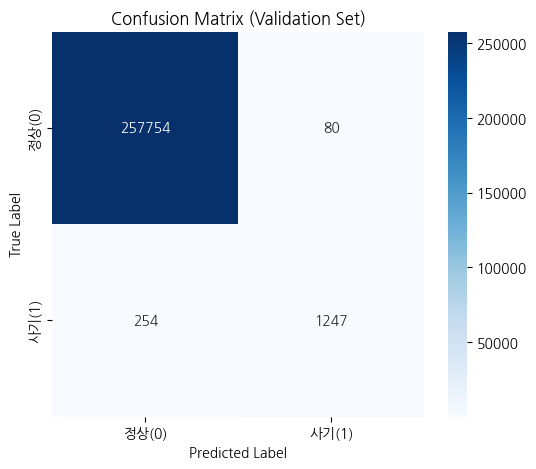



--- Test Set 평가 결과 ---
   Precision  Recall  F1-Score   ROC_AUC
0   0.823045  0.4662  0.595238  0.980336

Classification Report:
              precision    recall  f1-score   support

           0     0.9979    0.9996    0.9988    553574
           1     0.8230    0.4662    0.5952      2145

    accuracy                         0.9976    555719
   macro avg     0.9105    0.7329    0.7970    555719
weighted avg     0.9973    0.9976    0.9972    555719



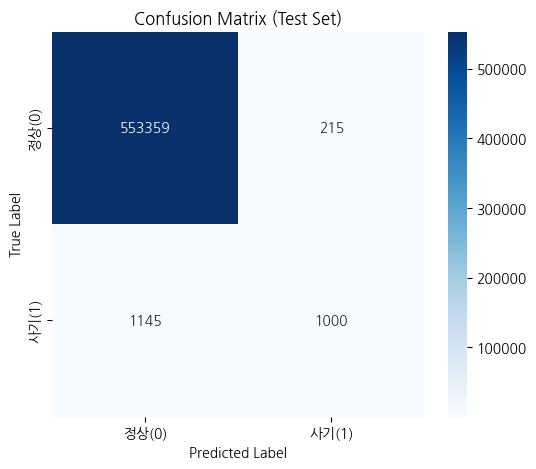

In [63]:
# 검증 데이터 평가
print("\n" + "="*50)
stacking_results = evaluate_and_visualize(stacking_model_baseline, X_val_scaled_baseline, y_val_final_baseline, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
test_results = evaluate_and_visualize(stacking_model_baseline, X_test_scaled_baseline, y_test_final_baseline, "Test Set")

# 3. stacking 단일

In [64]:
print("\n최종 데이터셋 생성 및 스케일링 시작 (스태킹 모델 전용)...\n")

# 피처(X)와 타겟(y) 분리
# 원-핫 인코딩된 'train_final_base' 데이터를 스태킹에 바로 사용합니다.
X_train_for_stacking = train_final_base.drop('is_fraud', axis=1)
y_train_for_stacking = train_final_base['is_fraud']

X_val_for_stacking = val_final_base.drop('is_fraud', axis=1).reindex(columns=X_train_for_stacking.columns, fill_value=0)
y_val_for_stacking = val_final_base['is_fraud']

X_test_for_stacking = test_final_base.drop('is_fraud', axis=1).reindex(columns=X_train_for_stacking.columns, fill_value=0)
y_test_for_stacking = test_final_base['is_fraud']

# --- 스케일링 로직: 'is_fraud'를 제외한 순수 수치형(int64, float64) 피처만 스케일링 ---

# 스케일링할 수치형 컬럼 식별 (Isolation Forest에서 사용된 방식과 동일)
# 이는 타겟인 'is_fraud'를 제외한 모든 int64 및 float64 컬럼을 선택합니다.
cols_to_scale_for_stacking = X_train_for_stacking.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 원본 DataFrame을 직접 수정하지 않기 위해 복사본 생성
X_train_scaled_for_stacking = X_train_for_stacking.copy()
X_val_scaled_for_stacking = X_val_for_stacking.copy()
X_test_scaled_for_stacking = X_test_for_stacking.copy()

# StandardScaler 초기화
scaler_for_stacking = StandardScaler()

# 식별된 수치형 컬럼에만 스케일러 적용
if cols_to_scale_for_stacking:
    X_train_scaled_for_stacking[cols_to_scale_for_stacking] = scaler_for_stacking.fit_transform(X_train_scaled_for_stacking[cols_to_scale_for_stacking])
    X_val_scaled_for_stacking[cols_to_scale_for_stacking] = scaler_for_stacking.transform(X_val_scaled_for_stacking[cols_to_scale_for_stacking])
    X_test_scaled_for_stacking[cols_to_scale_for_stacking] = scaler_for_stacking.transform(X_test_scaled_for_stacking[cols_to_scale_for_stacking])
else:
    print("경고: 스케일링할 수치형 피처(int64, float64)를 찾을 수 없습니다.")


print(f"-> 스케일링된 피처: {cols_to_scale_for_stacking}")
print("-> 스케일링 완료.")
print("\n" + "="*50 + "\n모든 작업이 완료되었습니다.\n" + "="*50)
print("최종 학습 데이터 형태:", X_train_scaled_for_stacking.shape)
print("최종 검증 데이터 형태:", X_val_scaled_for_stacking.shape)
print("최종 테스트 데이터 형태:", X_test_scaled_for_stacking.shape)


최종 데이터셋 생성 및 스케일링 시작 (스태킹 모델 전용)...

-> 스케일링된 피처: ['job_encoded', 'amt_log_std', 'trans_hour_sin', 'trans_hour_cos', 'cnt_1d', 'cnt_7d', 'cnt_30d', 'time_since_last_trans', 'age', 'city_state_encoded']
-> 스케일링 완료.

모든 작업이 완료되었습니다.
최종 학습 데이터 형태: (1092340, 32)
최종 검증 데이터 형태: (259335, 32)
최종 테스트 데이터 형태: (555719, 32)


In [65]:
print("\n===== 스태킹(Stacking) 앙상블 모델 학습 시작 =====")

# 기본 모델들 정의
lgbm_clf_stacking = LGBMClassifier(random_state=42, n_jobs=-1)
xgb_clf_stacking = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
cat_clf_stacking = CatBoostClassifier(random_state=42, verbose=0)

# 최종 모델(Meta-Learner) 정의
meta_clf_stacking = LogisticRegression(random_state=42, n_jobs=-1)

# 스태킹 모델 구성
stacking_model_pure = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_clf_stacking),
        ('xgb', xgb_clf_stacking),
        ('cat', cat_clf_stacking)
    ],
    final_estimator=meta_clf_stacking,
    # cv=3, # 1단계 모델들의 예측값을 생성하기 위한 교차 검증 폴드 수
    n_jobs=-1
)

# 스태킹 모델 학습 (시간이 매우 오래 소요될 수 있습니다!)
print("\n스태킹 모델 학습을 시작합니다. (기본 모델 3개 학습 * CV 3회 = 총 9회 학습)")
stacking_model_pure.fit(X_train_scaled_for_stacking, y_train_for_stacking)
print("-> 스태킹 모델 학습 완료.")


===== 스태킹(Stacking) 앙상블 모델 학습 시작 =====

스태킹 모델 학습을 시작합니다. (기본 모델 3개 학습 * CV 3회 = 총 9회 학습)
-> 스태킹 모델 학습 완료.




--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.942642  0.832112  0.883935  0.997839

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9997    0.9994    257834
           1     0.9426    0.8321    0.8839      1501

    accuracy                         0.9987    259335
   macro avg     0.9708    0.9159    0.9416    259335
weighted avg     0.9987    0.9987    0.9987    259335



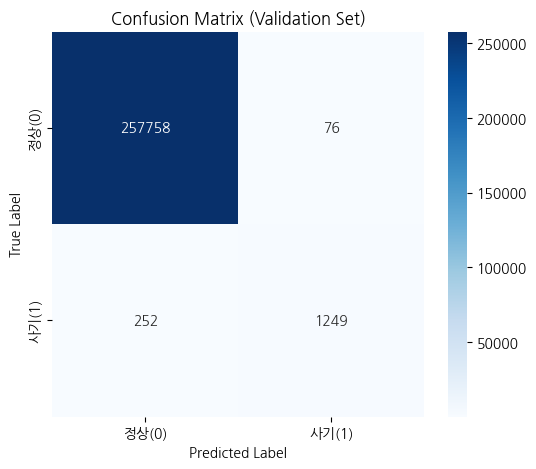



--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.840066  0.475058  0.606909  0.979244

Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9996    0.9988    553574
           1     0.8401    0.4751    0.6069      2145

    accuracy                         0.9976    555719
   macro avg     0.9190    0.7374    0.8029    555719
weighted avg     0.9974    0.9976    0.9973    555719



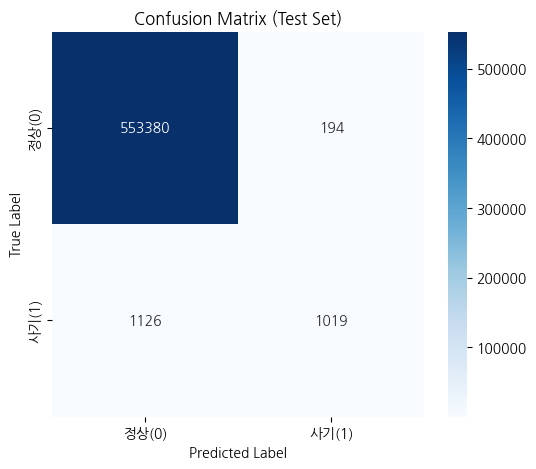

In [67]:
# 검증 데이터 평가
print("\n" + "="*50)
stacking_results = evaluate_and_visualize(stacking_model_pure, X_val_scaled_for_stacking, y_val_for_stacking, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
test_results = evaluate_and_visualize(stacking_model_pure, X_test_scaled_for_stacking, y_test_for_stacking, "Test Set")